In [1]:
pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path

BASE_DIR = Path(r"D:\current documents\Desktop\Final project\physio_net")
SET_A = BASE_DIR / "set-a"
OUTCOME_FILE = BASE_DIR / "Outcomes-a"

print("PhysioNet folder exists:", BASE_DIR.exists())
print("Set-A folder exists:", SET_A.exists())
print("Outcomes file exists:", OUTCOME_FILE.exists())

print("\nNumber of files in Set-A:")
print(len(list(SET_A.iterdir())))

PhysioNet folder exists: True
Set-A folder exists: True
Outcomes file exists: False

Number of files in Set-A:
4001


In [3]:
from pathlib import Path


BASE_DIR = Path(r"D:\current documents\Desktop\Final project\physio_net")
SET_A = BASE_DIR / "set-a"

# Automatically find the Outcomes file
outcome_files = list(BASE_DIR.glob("Outcomes-a*"))

print("PhysioNet folder exists:", BASE_DIR.exists())
print("Set-A folder exists:", SET_A.exists())
print("Outcome files found:", outcome_files)

if outcome_files:
    OUTCOME_FILE = outcome_files[0]
    print("Using outcome file:", OUTCOME_FILE)
    print("Outcome file exists:", OUTCOME_FILE.exists())
else:
    print("❌ Outcomes file was not found")

PhysioNet folder exists: True
Set-A folder exists: True
Outcome files found: [WindowsPath('D:/current documents/Desktop/Final project/physio_net/Outcomes-a.txt')]
Using outcome file: D:\current documents\Desktop\Final project\physio_net\Outcomes-a.txt
Outcome file exists: True


In [4]:
import pandas as pd

outcomes = pd.read_csv(OUTCOME_FILE)

print("Shape:", outcomes.shape)

print("\nColumns:")
print(outcomes.columns.tolist())

print("\nFirst 5 rows:")
display(outcomes.head())

print("\nOutcome counts:")
print(outcomes["In-hospital_death"].value_counts())

Shape: (4000, 6)

Columns:
['RecordID', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death']

First 5 rows:


,RecordID,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,132539,6,1,5,-1,0
1,132540,16,8,8,-1,0
2,132541,21,11,19,-1,0
3,132543,7,1,9,575,0
4,132545,17,2,4,918,0



Outcome counts:
In-hospital_death
0    3446
1     554
Name: count, dtype: int64


In [5]:
from pathlib import Path

# Your PhysioNet folders
BASE_DIR = Path(r"D:\current documents\Desktop\Final project\physio_net")
SET_A = BASE_DIR / "set-a"

# Find patient files
patient_files = [
    f for f in SET_A.iterdir()
    if f.is_file()
]

print("Number of files found:", len(patient_files))

# Select the first patient file
first_file = patient_files[0]

print("\nFirst patient file:")
print(first_file)

print("\nFile name:")
print(first_file.name)

print("\nFirst 30 lines:\n")

with open(first_file, "r") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 29:
            break

Number of files found: 4000

First patient file:
D:\current documents\Desktop\Final project\physio_net\set-a\132539.txt

File name:
132539.txt

First 30 lines:

Time,Parameter,Value
00:00,RecordID,132539
00:00,Age,54
00:00,Gender,0
00:00,Height,-1
00:00,ICUType,4
00:00,Weight,-1
00:07,GCS,15
00:07,HR,73
00:07,NIDiasABP,65
00:07,NIMAP,92.33
00:07,NISysABP,147
00:07,RespRate,19
00:07,Temp,35.1
00:07,Urine,900
00:37,HR,77
00:37,NIDiasABP,58
00:37,NIMAP,91
00:37,NISysABP,157
00:37,RespRate,19
00:37,Temp,35.6
00:37,Urine,60
01:37,HR,60
01:37,NIDiasABP,62
01:37,NIMAP,87
01:37,NISysABP,137
01:37,RespRate,18
01:37,Urine,30
02:37,HR,62
02:37,NIDiasABP,52


In [6]:
import pandas as pd
from pathlib import Path

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"D:\current documents\Desktop\Final project\physio_net")
SET_A = BASE_DIR / "set-a"

OUTPUT_FILE = BASE_DIR / "PhysioNet_all_patients.csv"

# ============================================================
# READ ALL PATIENT FILES
# ============================================================

all_data = []

patient_files = sorted(SET_A.glob("*.txt"))

print("Number of patient files:", len(patient_files))

for i, file in enumerate(patient_files):

    try:
        # Read patient file
        df = pd.read_csv(file)

        # Extract patient ID from filename
        patient_id = file.stem

        # Add patient ID
        df["patient_id"] = patient_id

        # Store
        all_data.append(df)

        # Progress
        if (i + 1) % 500 == 0:
            print(f"Processed {i + 1} patients...")

    except Exception as e:
        print(f"Error reading {file.name}: {e}")

# ============================================================
# COMBINE ALL PATIENTS
# ============================================================

physionet_df = pd.concat(all_data, ignore_index=True)

print("\n====================================")
print("COMBINATION COMPLETE")
print("====================================")

print("Shape:", physionet_df.shape)

print("\nColumns:")
print(physionet_df.columns.tolist())

print("\nFirst 10 rows:")
display(physionet_df.head(10))

# ============================================================
# SAVE CSV
# ============================================================

physionet_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nSaved successfully:")
print(OUTPUT_FILE)

Number of patient files: 4000
Processed 500 patients...
Processed 1000 patients...
Processed 1500 patients...
Processed 2000 patients...
Processed 2500 patients...
Processed 3000 patients...
Processed 3500 patients...
Processed 4000 patients...

COMBINATION COMPLETE
Shape: (1757980, 4)

Columns:
['Time', 'Parameter', 'Value', 'patient_id']

First 10 rows:


,Time,Parameter,Value,patient_id
0,00:00,RecordID,132539.00,132539
1,00:00,Age,54.00,132539
2,00:00,Gender,0.00,132539
3,00:00,Height,-1.00,132539
4,00:00,ICUType,4.00,132539
5,00:00,Weight,-1.00,132539
6,00:07,GCS,15.00,132539
7,00:07,HR,73.00,132539
8,00:07,NIDiasABP,65.00,132539
9,00:07,NIMAP,92.33,132539



Saved successfully:
D:\current documents\Desktop\Final project\physio_net\PhysioNet_all_patients.csv


In [7]:
import pandas as pd

csv_path = r"D:\current documents\Desktop\Final project\physio_net\PhysioNet_all_patients.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print(df.head())

Shape: (1757980, 4)
    Time Parameter     Value  patient_id
0  00:00  RecordID  132539.0      132539
1  00:00       Age      54.0      132539
2  00:00    Gender       0.0      132539
3  00:00    Height      -1.0      132539
4  00:00   ICUType       4.0      132539


In [8]:
print("Number of unique parameters:", df["Parameter"].nunique())

print("\nAll parameters:")
print(sorted(df["Parameter"].dropna().unique()))

Number of unique parameters: 42

All parameters:
['ALP', 'ALT', 'AST', 'Age', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Gender', 'Glucose', 'HCO3', 'HCT', 'HR', 'Height', 'ICUType', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RecordID', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH']


In [9]:
parameter_counts = (
    df["Parameter"]
    .value_counts()
    .sort_values(ascending=False)
)

print(parameter_counts)

Parameter
HR             228538
MAP            145760
SysABP         145650
DiasABP        145567
Urine          136918
Weight         129165
NISysABP        98331
NIDiasABP       98210
NIMAP           96871
Temp            86405
GCS             61563
RespRate        55051
FiO2            32390
MechVent        31144
pH              24355
PaCO2           23293
PaO2            23268
HCT             18271
K               14440
Platelets       14104
Creatinine      13983
BUN             13916
HCO3            13613
Mg              13590
Na              13570
Glucose         13021
WBC             12910
SaO2             8185
Lactate          8024
Height           4000
RecordID         4000
Gender           4000
ICUType          4000
Age              4000
Bilirubin        3191
AST              3182
ALT              3177
ALP              3092
Albumin          2356
TroponinT        2126
TroponinI         435
Cholesterol       315
Name: count, dtype: int64


In [10]:
outcome_path = r"D:\current documents\Desktop\Final project\physio_net\Outcomes-a.txt"

outcomes = pd.read_csv(outcome_path)

print("Outcome shape:", outcomes.shape)

print("\nColumns:")
print(outcomes.columns.tolist())

print("\nFirst 5 rows:")
display(outcomes.head())

print("\nDeath counts:")
print(outcomes["In-hospital_death"].value_counts())

Outcome shape: (4000, 6)

Columns:
['RecordID', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death']

First 5 rows:


,RecordID,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,132539,6,1,5,-1,0
1,132540,16,8,8,-1,0
2,132541,21,11,19,-1,0
3,132543,7,1,9,575,0
4,132545,17,2,4,918,0



Death counts:
In-hospital_death
0    3446
1     554
Name: count, dtype: int64


In [11]:
print(sorted(df["Parameter"].dropna().unique()))
print(outcomes["In-hospital_death"].value_counts())

['ALP', 'ALT', 'AST', 'Age', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Gender', 'Glucose', 'HCO3', 'HCT', 'HR', 'Height', 'ICUType', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RecordID', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH']
In-hospital_death
0    3446
1     554
Name: count, dtype: int64


In [13]:
features = [
    "HR",
    "NIDiasABP",
    "NIMAP",
    "NISysABP",
    "RespRate",
    "Temp",
    "GCS",
    "Glucose",
    "SaO2",
    "Urine"
]

These are reasonable starting features because they represent cardiovascular, respiratory, neurological and metabolic status.

In [14]:
#create time series table
# Features for the LSTM
features = [
    "HR",
    "NIDiasABP",
    "NIMAP",
    "NISysABP",
    "RespRate",
    "Temp",
    "GCS",
    "Glucose",
    "SaO2",
    "Urine"
]

# Keep only the required parameters
df_lstm = df[df["Parameter"].isin(features)].copy()

print("Filtered shape:", df_lstm.shape)

# Convert Value to numeric
df_lstm["Value"] = pd.to_numeric(
    df_lstm["Value"],
    errors="coerce"
)

# Convert Time to minutes
def time_to_minutes(x):
    try:
        h, m = str(x).split(":")
        return int(h) * 60 + int(m)
    except:
        return None

df_lstm["Time_minutes"] = df_lstm["Time"].apply(time_to_minutes)

print("\nFirst rows:")
display(df_lstm.head(10))

Filtered shape: (883093, 4)

First rows:


,Time,Parameter,Value,patient_id,Time_minutes
6,00:07,GCS,15.00,132539,7
7,00:07,HR,73.00,132539,7
8,00:07,NIDiasABP,65.00,132539,7
9,00:07,NIMAP,92.33,132539,7
10,00:07,NISysABP,147.00,132539,7
11,00:07,RespRate,19.00,132539,7
12,00:07,Temp,35.10,132539,7
13,00:07,Urine,900.00,132539,7
14,00:37,HR,77.00,132539,37
15,00:37,NIDiasABP,58.00,132539,37


In [15]:
#pviot the parameters
df_wide = df_lstm.pivot_table(
    index=["patient_id", "Time_minutes"],
    columns="Parameter",
    values="Value",
    aggfunc="mean"
).reset_index()

# Remove the column name created by pivot
df_wide.columns.name = None

print("Wide dataset shape:", df_wide.shape)

print("\nColumns:")
print(df_wide.columns.tolist())

print("\nFirst 10 rows:")
display(df_wide.head(10))

Wide dataset shape: (252806, 12)

Columns:
['patient_id', 'Time_minutes', 'GCS', 'Glucose', 'HR', 'NIDiasABP', 'NIMAP', 'NISysABP', 'RespRate', 'SaO2', 'Temp', 'Urine']

First 10 rows:


,patient_id,Time_minutes,GCS,Glucose,HR,NIDiasABP,NIMAP,NISysABP,RespRate,SaO2,Temp,Urine
0,132539,7,15.0,NaN,73.0,65.0,92.33,147.0,19.0,NaN,35.1,900.0
1,132539,37,NaN,NaN,77.0,58.0,91.00,157.0,19.0,NaN,35.6,60.0
2,132539,97,NaN,NaN,60.0,62.0,87.00,137.0,18.0,NaN,NaN,30.0
3,132539,157,NaN,NaN,62.0,52.0,75.67,123.0,19.0,NaN,NaN,170.0
4,132539,217,15.0,NaN,80.0,52.0,72.67,114.0,20.0,NaN,37.8,60.0
5,132539,277,NaN,NaN,74.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN
6,132539,337,NaN,NaN,73.0,45.0,66.67,110.0,17.0,NaN,NaN,170.0
7,132539,457,15.0,NaN,64.0,49.0,68.33,107.0,15.0,NaN,38.1,120.0
8,132539,517,NaN,NaN,64.0,56.0,71.33,102.0,14.0,NaN,NaN,80.0
9,132539,577,NaN,NaN,66.0,48.0,70.00,114.0,17.0,NaN,NaN,100.0


In [16]:
#add the outcome
# Make patient ID numeric
df_wide["patient_id"] = pd.to_numeric(
    df_wide["patient_id"],
    errors="coerce"
)

# Prepare outcome data
outcome_small = outcomes[
    ["RecordID", "In-hospital_death"]
].copy()

outcome_small["RecordID"] = pd.to_numeric(
    outcome_small["RecordID"],
    errors="coerce"
)

# Rename RecordID to patient_id
outcome_small = outcome_small.rename(
    columns={"RecordID": "patient_id"}
)

# Merge
df_wide = df_wide.merge(
    outcome_small,
    on="patient_id",
    how="inner"
)

print("After merging outcome:")
print("Shape:", df_wide.shape)

print("\nOutcome counts:")
print(df_wide["In-hospital_death"].value_counts())

display(df_wide.head())

After merging outcome:
Shape: (252806, 13)

Outcome counts:
In-hospital_death
0    216108
1     36698
Name: count, dtype: int64


,patient_id,Time_minutes,GCS,Glucose,HR,NIDiasABP,NIMAP,NISysABP,RespRate,SaO2,Temp,Urine,In-hospital_death
0,132539,7,15.0,NaN,73.0,65.0,92.33,147.0,19.0,NaN,35.1,900.0,0
1,132539,37,NaN,NaN,77.0,58.0,91.00,157.0,19.0,NaN,35.6,60.0,0
2,132539,97,NaN,NaN,60.0,62.0,87.00,137.0,18.0,NaN,NaN,30.0,0
3,132539,157,NaN,NaN,62.0,52.0,75.67,123.0,19.0,NaN,NaN,170.0,0
4,132539,217,15.0,NaN,80.0,52.0,72.67,114.0,20.0,NaN,37.8,60.0,0


In [17]:
print("Number of patients:", df_wide["patient_id"].nunique())

Number of patients: 3996


In [18]:
#hourly time-series data convert to hourly data
import numpy as np
import pandas as pd

# Features we selected
features = [
    "HR",
    "NIDiasABP",
    "NIMAP",
    "NISysABP",
    "RespRate",
    "Temp",
    "GCS",
    "Glucose",
    "SaO2",
    "Urine"
]

# Make a copy
hourly_df = df_wide.copy()

# Convert time to hour number
hourly_df["hour"] = (
    hourly_df["Time_minutes"] // 60
).astype(int)

# Keep only first 48 hours
hourly_df = hourly_df[
    hourly_df["hour"] < 48
].copy()

print("Rows after keeping first 48 hours:", hourly_df.shape)

print("\nNumber of patients:")
print(hourly_df["patient_id"].nunique())

print("\nHour range:")
print(hourly_df["hour"].min(), "to", hourly_df["hour"].max())

Rows after keeping first 48 hours: (252737, 14)

Number of patients:
3996

Hour range:
0 to 47


In [19]:
#combine measurements within each hour
hourly_features = (
    hourly_df
    .groupby(["patient_id", "hour"])[features]
    .mean()
    .reset_index()
)

print("Hourly feature shape:", hourly_features.shape)

display(hourly_features.head(10))

Hourly feature shape: (175702, 12)


,patient_id,hour,HR,NIDiasABP,NIMAP,NISysABP,RespRate,Temp,GCS,Glucose,SaO2,Urine
0,132539,0,75.0,61.5,91.665,152.0,19.0,35.35,15.0,NaN,NaN,480.0
1,132539,1,60.0,62.0,87.000,137.0,18.0,NaN,NaN,NaN,NaN,30.0
2,132539,2,62.0,52.0,75.670,123.0,19.0,NaN,NaN,NaN,NaN,170.0
3,132539,3,80.0,52.0,72.670,114.0,20.0,37.80,15.0,NaN,NaN,60.0
4,132539,4,74.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN,NaN
5,132539,5,73.0,45.0,66.670,110.0,17.0,NaN,NaN,NaN,NaN,170.0
6,132539,7,64.0,49.0,68.330,107.0,15.0,38.10,15.0,NaN,NaN,120.0
7,132539,8,64.0,56.0,71.330,102.0,14.0,NaN,NaN,NaN,NaN,80.0
8,132539,9,66.0,48.0,70.000,114.0,17.0,NaN,NaN,NaN,NaN,100.0
9,132539,10,61.0,62.0,77.670,109.0,15.0,NaN,NaN,205.0,NaN,60.0


In [20]:
#add the outcome look
patient_outcomes = (
    df_wide[
        ["patient_id", "In-hospital_death"]
    ]
    .drop_duplicates("patient_id")
)

hourly_features = hourly_features.merge(
    patient_outcomes,
    on="patient_id",
    how="left"
)

print("Shape:", hourly_features.shape)

print("\nPatients:", hourly_features["patient_id"].nunique())

print("\nOutcome distribution:")
print(
    patient_outcomes["In-hospital_death"]
    .value_counts()
)

Shape: (175702, 13)

Patients: 3996

Outcome distribution:
In-hospital_death
0    3442
1     554
Name: count, dtype: int64


In [21]:
#check missing value
print("Missing values:")
print(
    hourly_features[features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

Missing values:
SaO2         167812
Glucose      162714
RespRate     129847
GCS          114650
Temp         104489
NIMAP         95954
NIDiasABP     94941
NISysABP      94848
Urine         42861
HR             2819
dtype: int64


In [22]:
print([name for name in globals() if not name.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'Path', 'BASE_DIR', 'SET_A', 'OUTCOME_FILE', 'outcome_files', 'pd', 'outcomes', 'patient_files', 'first_file', 'f', 'i', 'line', 'OUTPUT_FILE', 'all_data', 'file', 'df', 'patient_id', 'physionet_df', 'csv_path', 'parameter_counts', 'outcome_path', 'features', 'df_lstm', 'time_to_minutes', 'df_wide', 'outcome_small', 'np', 'hourly_df', 'hourly_features', 'patient_outcomes']


In [23]:
print(hourly_df.shape)
print(hourly_df.columns.tolist())
print(hourly_df.head())

(252737, 14)
['patient_id', 'Time_minutes', 'GCS', 'Glucose', 'HR', 'NIDiasABP', 'NIMAP', 'NISysABP', 'RespRate', 'SaO2', 'Temp', 'Urine', 'In-hospital_death', 'hour']
   patient_id  Time_minutes   GCS  Glucose    HR  NIDiasABP  NIMAP  NISysABP  \
0      132539             7  15.0      NaN  73.0       65.0  92.33     147.0   
1      132539            37   NaN      NaN  77.0       58.0  91.00     157.0   
2      132539            97   NaN      NaN  60.0       62.0  87.00     137.0   
3      132539           157   NaN      NaN  62.0       52.0  75.67     123.0   
4      132539           217  15.0      NaN  80.0       52.0  72.67     114.0   

   RespRate  SaO2  Temp  Urine  In-hospital_death  hour  
0      19.0   NaN  35.1  900.0                  0     0  
1      19.0   NaN  35.6   60.0                  0     0  
2      18.0   NaN   NaN   30.0                  0     1  
3      19.0   NaN   NaN  170.0                  0     2  
4      20.0   NaN  37.8   60.0                  0     3  


In [24]:
hours_per_patient = (
    hourly_df
    .groupby("patient_id")["hour"]
    .nunique()
)

print("Patients:", len(hours_per_patient))

print("\nHours available per patient:")
print(hours_per_patient.describe())

print("\nPatients with at least 48 hours:")
print((hours_per_patient >= 48).sum())

print("\nPatients with fewer than 48 hours:")
print((hours_per_patient < 48).sum())

print("\nMinimum hours:", hours_per_patient.min())
print("Maximum hours:", hours_per_patient.max())

Patients: 3996

Hours available per patient:
count    3996.000000
mean       43.969469
std         6.477114
min         1.000000
25%        43.000000
50%        46.000000
75%        47.000000
max        48.000000
Name: hour, dtype: float64

Patients with at least 48 hours:
720

Patients with fewer than 48 hours:
3276

Minimum hours: 1
Maximum hours: 48


In [25]:
# ============================================================
# STEP 13: HANDLE MISSING VALUES
# ============================================================

# Make a copy
hourly_clean = hourly_features.copy()

# Sort by patient and hour
hourly_clean = hourly_clean.sort_values(
    ["patient_id", "hour"]
).reset_index(drop=True)

print("Before filling missing values:")
print(hourly_clean[features].isna().sum())

# Forward fill within each patient
hourly_clean[features] = (
    hourly_clean
    .groupby("patient_id")[features]
    .ffill()
)

# Backward fill within each patient
hourly_clean[features] = (
    hourly_clean
    .groupby("patient_id")[features]
    .bfill()
)

# Fill anything still missing with feature median
for feature in features:
    median_value = hourly_clean[feature].median()
    hourly_clean[feature] = (
        hourly_clean[feature].fillna(median_value)
    )

print("\nAfter filling missing values:")
print(hourly_clean[features].isna().sum())

print("\nShape:", hourly_clean.shape)
print("Patients:", hourly_clean["patient_id"].nunique())

Before filling missing values:
HR             2819
NIDiasABP     94941
NIMAP         95954
NISysABP      94848
RespRate     129847
Temp         104489
GCS          114650
Glucose      162714
SaO2         167812
Urine         42861
dtype: int64

After filling missing values:
HR           0
NIDiasABP    0
NIMAP        0
NISysABP     0
RespRate     0
Temp         0
GCS          0
Glucose      0
SaO2         0
Urine        0
dtype: int64

Shape: (175702, 13)
Patients: 3996


In [26]:
hours_per_patient = (
    hourly_clean
    .groupby("patient_id")["hour"]
    .nunique()
)

print("Patients:", len(hours_per_patient))

print("\nHours available per patient:")
print(hours_per_patient.describe())

print("\nPatients with at least 48 hours:")
print((hours_per_patient >= 48).sum())

print("\nPatients with fewer than 48 hours:")
print((hours_per_patient < 48).sum())

print("\nMinimum hours:", hours_per_patient.min())
print("Maximum hours:", hours_per_patient.max())

Patients: 3996

Hours available per patient:
count    3996.000000
mean       43.969469
std         6.477114
min         1.000000
25%        43.000000
50%        46.000000
75%        47.000000
max        48.000000
Name: hour, dtype: float64

Patients with at least 48 hours:
720

Patients with fewer than 48 hours:
3276

Minimum hours: 1
Maximum hours: 48


In [59]:
#Create complete 48-hour sequences
import numpy as np
import pandas as pd

# ============================================================
# STEP 15: CREATE 0-47 HOURS FOR EVERY PATIENT
# ============================================================

# Keep patient outcome
patient_outcomes = (
    hourly_clean[
        ["patient_id", "In-hospital_death"]
    ]
    .drop_duplicates("patient_id")
)

# Create every patient × every hour
patients = hourly_clean["patient_id"].unique()

all_hours = pd.MultiIndex.from_product(
    [patients, range(48)],
    names=["patient_id", "hour"]
)

complete_df = all_hours.to_frame(index=False)

# Merge the existing hourly measurements
complete_df = complete_df.merge(
    hourly_clean[
        ["patient_id", "hour"] + features
    ],
    on=["patient_id", "hour"],
    how="left"
)

# Add outcome
complete_df = complete_df.merge(
    patient_outcomes,
    on="patient_id",
    how="left"
)

# Sort
complete_df = complete_df.sort_values(
    ["patient_id", "hour"]
).reset_index(drop=True)

print("Complete dataset shape:", complete_df.shape)

print("\nExpected rows:")
print(3996 * 48)

print("\nPatients:")
print(complete_df["patient_id"].nunique())

print("\nHours:")
print(complete_df["hour"].nunique())

display(complete_df.head(50))

Complete dataset shape: (191808, 13)

Expected rows:
191808

Patients:
3996

Hours:
48


,patient_id,hour,HR,NIDiasABP,NIMAP,NISysABP,RespRate,Temp,GCS,Glucose,SaO2,Urine,In-hospital_death
0,132539,0,75.0,61.500000,91.665,152.000000,19.0,35.35,15.0,205.0,98.0,480.000000,0
1,132539,1,60.0,62.000000,87.000,137.000000,18.0,35.35,15.0,205.0,98.0,30.000000,0
2,132539,2,62.0,52.000000,75.670,123.000000,19.0,35.35,15.0,205.0,98.0,170.000000,0
3,132539,3,80.0,52.000000,72.670,114.000000,20.0,37.80,15.0,205.0,98.0,60.000000,0
4,132539,4,74.0,52.000000,72.670,114.000000,20.0,37.80,15.0,205.0,98.0,60.000000,0
5,132539,5,73.0,45.000000,66.670,110.000000,17.0,37.80,15.0,205.0,98.0,170.000000,0
6,132539,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
7,132539,7,64.0,49.000000,68.330,107.000000,15.0,38.10,15.0,205.0,98.0,120.000000,0
8,132539,8,64.0,56.000000,71.330,102.000000,14.0,38.10,15.0,205.0,98.0,80.000000,0
9,132539,9,66.0,48.000000,70.000,114.000000,17.0,38.10,15.0,205.0,98.0,100.000000,0


In [58]:
#Fill the newly created missing hours


complete_df[features] = (
    complete_df
    .groupby("patient_id")[features]
    .ffill()
)

complete_df[features] = (
    complete_df
    .groupby("patient_id")[features]
    .bfill()
)

# Fill any remaining missing values with feature median
for feature in features:
    median_value = complete_df[feature].median()
    complete_df[feature] = (
        complete_df[feature]
        .fillna(median_value)
    )

print("Missing values after filling:")

print(
    complete_df[features]
    .isna()
    .sum()
)

Missing values after filling:
HR           0
NIDiasABP    0
NIMAP        0
NISysABP     0
RespRate     0
Temp         0
GCS          0
Glucose      0
SaO2         0
Urine        0
dtype: int64


In [29]:
#Create X and y

X_list = []
y_list = []

for patient_id, group in complete_df.groupby("patient_id"):

    # Sort by hour
    group = group.sort_values("hour")

    # Extract 48 × 10 features
    sequence = group[features].values

    # Extract outcome
    outcome = group["In-hospital_death"].iloc[0]

    X_list.append(sequence)
    y_list.append(outcome)

# Convert to NumPy arrays
X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst patient sequence shape:")
print(X[0].shape)

print("\nFirst patient outcome:")
print(y[0])


X shape: (3996, 48, 10)
y shape: (3996,)

First patient sequence shape:
(48, 10)

First patient outcome:
0


In [30]:
#Split the data into Train and Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining outcome:")
print(pd.Series(y_train).value_counts())

print("\nTesting outcome:")
print(pd.Series(y_test).value_counts())

X_train: (3196, 48, 10)
X_test : (800, 48, 10)
y_train: (3196,)
y_test : (800,)

Training outcome:
0    2753
1     443
Name: count, dtype: int64

Testing outcome:
0    689
1    111
Name: count, dtype: int64


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Convert 3D → 2D for scaling
X_train_2d = X_train.reshape(-1, X_train.shape[-1])

# Fit ONLY on training data
scaler.fit(X_train_2d)

# Scale training data
X_train_scaled = scaler.transform(
    X_train_2d
).reshape(X_train.shape)

# Scale test data using the same scaler
X_test_scaled = scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (3196, 48, 10)
X_test_scaled : (800, 48, 10)


In [32]:
#Calculate class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Classes:", classes)
print("Class weights:", class_weights)

Classes: [0 1]
Class weights: {np.int32(0): np.float64(0.5804576825281511), np.int32(1): np.float64(3.6072234762979685)}


In [33]:
#build the lstm model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

model = Sequential([
    Input(shape=(48, 10)),

    LSTM(64, return_sequences=False),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

TensorFlow version: 2.21.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
#train
early_stopping = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,

    validation_split=0.2,

    epochs=30,
    batch_size=32,

    class_weight=class_weights,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.6287 - auc: 0.7092 - loss: 0.6228 - precision: 0.2211 - recall: 0.6752 - val_accuracy: 0.7203 - val_auc: 0.7611 - val_loss: 0.5667 - val_precision: 0.2938 - val_recall: 0.6739
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7179 - auc: 0.7786 - loss: 0.5617 - precision: 0.2839 - recall: 0.6923 - val_accuracy: 0.6828 - val_auc: 0.7705 - val_loss: 0.5718 - val_precision: 0.2716 - val_recall: 0.7174
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6944 - auc: 0.7954 - loss: 0.5467 - precision: 0.2784 - recall: 0.7692 - val_accuracy: 0.7469 - val_auc: 0.7927 - val_loss: 0.4744 - val_precision: 0.3158 - val_recall: 0.6522
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7171 - auc: 0.8018 - loss: 0.5376 - precision: 0.2919 - recall: 0.7436 - val_accuracy: 0.6609 - val_auc: 0.7684 - val_loss: 0.5995 - val_precision: 0.2605 - val_recall: 0.7391
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━

In [35]:
#check best epoch
print("Best validation AUC:",
      max(history.history["val_auc"]))

print("Best validation recall:",
      max(history.history["val_recall"]))

print("Best validation accuracy:",
      max(history.history["val_accuracy"]))

Best validation AUC: 0.7926948070526123
Best validation recall: 0.739130437374115
Best validation accuracy: 0.746874988079071


In [36]:
#test the model
results = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print("\nTest Results:")

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7350 - auc: 0.8038 - loss: 0.4773 - precision: 0.2972 - recall: 0.6667

Test Results:
loss: 0.4773
compile_metrics: 0.7350


In [37]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict probabilities
y_prob = model.predict(X_test_scaled).ravel()

# Convert probability to class
y_pred = (y_prob >= 0.5).astype(int)

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Survived", "Died"]
    )
)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Classification Report:
              precision    recall  f1-score   support

    Survived       0.93      0.75      0.83       689
        Died       0.30      0.67      0.41       111

    accuracy                           0.73       800
   macro avg       0.62      0.71      0.62       800
weighted avg       0.84      0.73      0.77       800


Confusion Matrix:
[[514 175]
 [ 37  74]]


In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get probability predictions
y_prob = model.predict(X_test).ravel()

# Try different thresholds
for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:

    y_pred = (y_prob >= threshold).astype(int)

    print("\n" + "=" * 50)
    print("Threshold:", threshold)
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Survived", "Died"],
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Threshold: 0.3
              precision    recall  f1-score   support

    Survived       0.95      0.54      0.69       689
        Died       0.22      0.81      0.35       111

    accuracy                           0.58       800
   macro avg       0.58      0.68      0.52       800
weighted avg       0.85      0.58      0.64       800

Confusion Matrix:
[[374 315]
 [ 21  90]]

Threshold: 0.35
              precision    recall  f1-score   support

    Survived       0.92      0.63      0.75       689
        Died       0.22      0.66      0.33       111

    accuracy                           0.64       800
   macro avg       0.57      0.64      0.54       800
weighted avg       0.82      0.64      0.69       800

Confusion Matrix:
[[435 254]
 [ 38  73]]

Threshold: 0.4
              precision    recall  f1-score   support

    Survived       0.91      0.77      0.83       689
        Died       0.27      0.54      0.36       111

    accurac

In [39]:
import numpy as np

y_prob = model.predict(X_test).ravel()

print("Minimum probability:", y_prob.min())
print("Maximum probability:", y_prob.max())
print("Mean probability:", y_prob.mean())

print("\nFirst 20 probabilities:")
print(y_prob[:20])

print("\nProbability percentiles:")
print(np.percentile(y_prob, [0, 10, 25, 50, 75, 90, 95, 99, 100]))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Minimum probability: 0.11370913
Maximum probability: 0.63099
Mean probability: 0.31403628

First 20 probabilities:
[0.16566712 0.47051212 0.49742773 0.49491957 0.17424838 0.24513346
 0.42697176 0.27545404 0.15530191 0.27761066 0.27532956 0.33463386
 0.44450134 0.42441088 0.32306346 0.122417   0.18646483 0.22412212
 0.19970621 0.47108167]

Probability percentiles:
[0.11370913 0.17127694 0.20498437 0.30327402 0.41066713 0.47031088
 0.50313295 0.57078103 0.63099003]


In [40]:
print("Unique y_test values:", np.unique(y_test, return_counts=True))
for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:

    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    print("\nThreshold:", threshold)
    print(cm)

    print(classification_report(
        y_test,
        y_pred,
        target_names=["Survived", "Died"],
        zero_division=0
    ))

Unique y_test values: (array([0, 1], dtype=int32), array([689, 111]))

Threshold: 0.3
[[374 315]
 [ 21  90]]
              precision    recall  f1-score   support

    Survived       0.95      0.54      0.69       689
        Died       0.22      0.81      0.35       111

    accuracy                           0.58       800
   macro avg       0.58      0.68      0.52       800
weighted avg       0.85      0.58      0.64       800


Threshold: 0.35
[[435 254]
 [ 38  73]]
              precision    recall  f1-score   support

    Survived       0.92      0.63      0.75       689
        Died       0.22      0.66      0.33       111

    accuracy                           0.64       800
   macro avg       0.57      0.64      0.54       800
weighted avg       0.82      0.64      0.69       800


Threshold: 0.4
[[528 161]
 [ 51  60]]
              precision    recall  f1-score   support

    Survived       0.91      0.77      0.83       689
        Died       0.27      0.54      0.36      

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predict probabilities for test data
y_prob = model.predict(X_test_scaled).ravel()

# Convert probability to class using 0.5 threshold
y_pred = (y_prob >= 0.5).astype(int)

# Test ROC-AUC
test_auc = roc_auc_score(y_test, y_prob)

print("Test ROC-AUC:", test_auc)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Survived", "Died"],
        zero_division=0
    )
)

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Test ROC-AUC: 0.8037238980635206

Classification Report:
              precision    recall  f1-score   support

    Survived       0.93      0.75      0.83       689
        Died       0.30      0.67      0.41       111

    accuracy                           0.73       800
   macro avg       0.62      0.71      0.62       800
weighted avg       0.84      0.73      0.77       800


Confusion Matrix:
[[514 175]
 [ 37  74]]


LSTM TESTING AND EVALUATION

Test samples: 800
Predicted samples: 800

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Survived       0.93      0.75      0.83       689
        Died       0.30      0.67      0.41       111

    accuracy                           0.73       800
   macro avg       0.62      0.71      0.62       800
weighted avg       0.84      0.73      0.77       800

CONFUSION MATRIX
[[514 175]
 [ 37  74]]

Test ROC-AUC: 0.8037


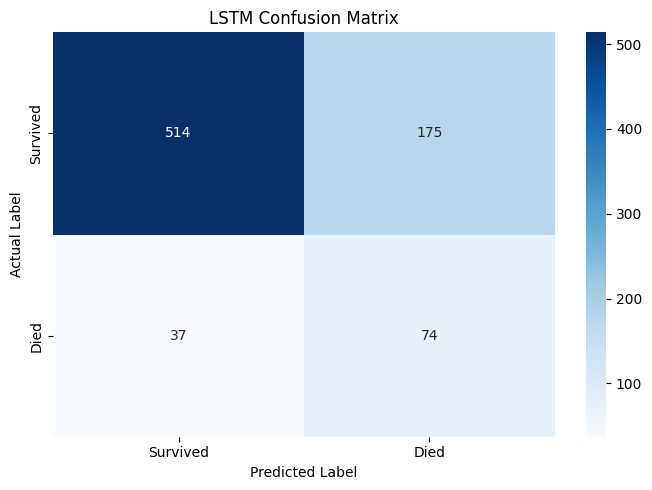

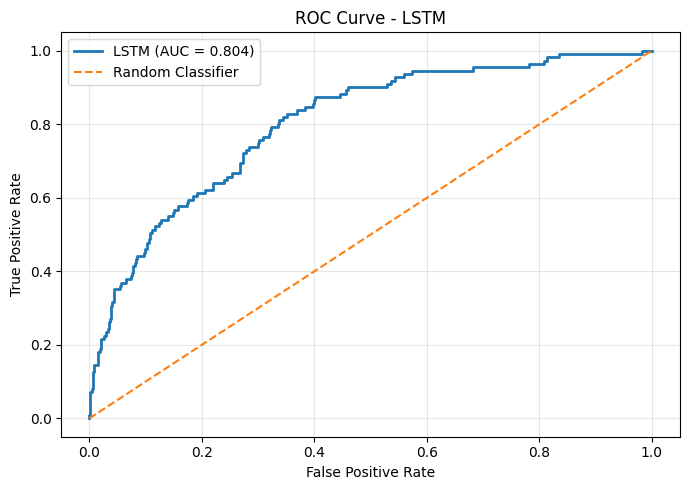

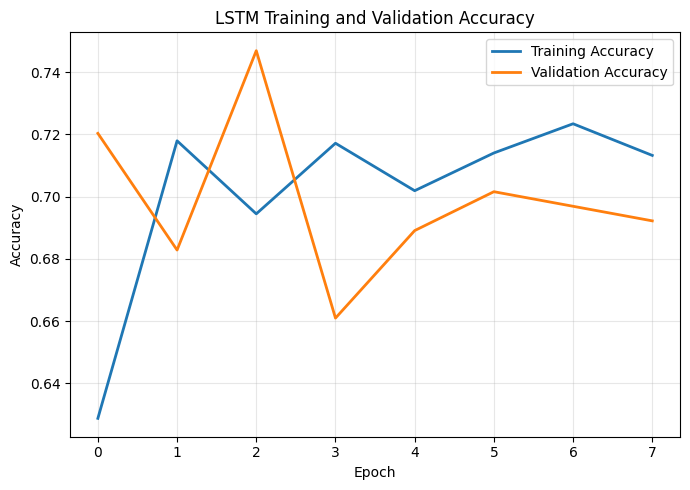

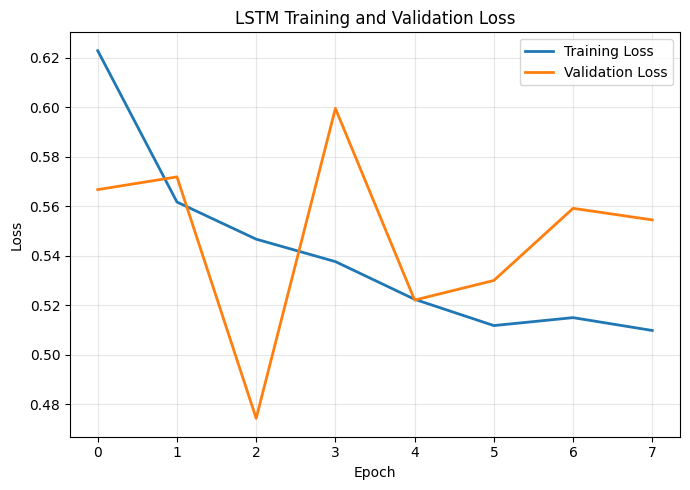

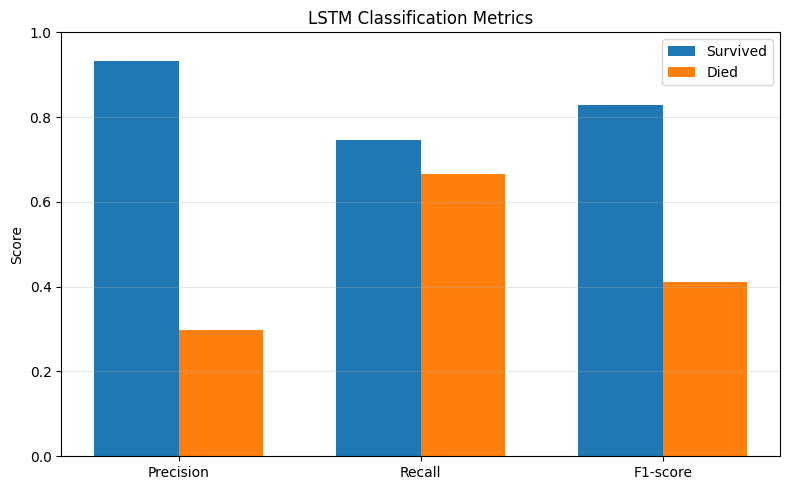


FINAL TEST RESULTS
Test Accuracy : 0.7350
Test ROC-AUC  : 0.8037

Survived:
  Precision : 0.9328
  Recall    : 0.7460
  F1-score  : 0.8290

Died:
  Precision : 0.2972
  Recall    : 0.6667
  F1-score  : 0.4111

EVALUATION COMPLETE


In [42]:
# ============================================================
# COMPLETE LSTM MODEL EVALUATION
# Uses existing: model, history, X_test_scaled, y_test
# No retraining required
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_fscore_support
)

# ------------------------------------------------------------
# 1. PREDICT ON TEST DATA
# ------------------------------------------------------------

print("=" * 60)
print("LSTM TESTING AND EVALUATION")
print("=" * 60)

y_prob = model.predict(X_test_scaled, verbose=0).ravel()

# Default threshold = 0.5
y_pred = (y_prob >= 0.5).astype(int)

print("\nTest samples:", len(y_test))
print("Predicted samples:", len(y_pred))


# ------------------------------------------------------------
# 2. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(
    y_test,
    y_pred,
    target_names=["Survived", "Died"],
    zero_division=0
)

print(report)


# ------------------------------------------------------------
# 3. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
print(cm)


# ------------------------------------------------------------
# 4. TEST ROC-AUC
# ------------------------------------------------------------

test_auc = roc_auc_score(y_test, y_prob)

print("\nTest ROC-AUC:", round(test_auc, 4))


# ============================================================
# GRAPH 1 — CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Survived", "Died"],
    yticklabels=["Survived", "Died"]
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2 — ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"LSTM (AUC = {test_auc:.3f})",
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 3 — TRAINING & VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

if "val_accuracy" in history.history:
    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy",
        linewidth=2
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 4 — TRAINING & VALIDATION LOSS
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

if "val_loss" in history.history:
    plt.plot(
        history.history["val_loss"],
        label="Validation Loss",
        linewidth=2
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 5 — PRECISION, RECALL, F1-SCORE
# ============================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=[0, 1],
    zero_division=0
)

metrics = ["Precision", "Recall", "F1-score"]

survived_values = [
    precision[0],
    recall[0],
    f1[0]
]

died_values = [
    precision[1],
    recall[1],
    f1[1]
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    survived_values,
    width,
    label="Survived"
)

plt.bar(
    x + width / 2,
    died_values,
    width,
    label="Died"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("LSTM Classification Metrics")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 6. FINAL SUMMARY
# ============================================================

accuracy = np.mean(y_test == y_pred)

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"Test Accuracy : {accuracy:.4f}")
print(f"Test ROC-AUC  : {test_auc:.4f}")

print("\nSurvived:")
print(f"  Precision : {precision[0]:.4f}")
print(f"  Recall    : {recall[0]:.4f}")
print(f"  F1-score  : {f1[0]:.4f}")

print("\nDied:")
print(f"  Precision : {precision[1]:.4f}")
print(f"  Recall    : {recall[1]:.4f}")
print(f"  F1-score  : {f1[1]:.4f}")

print("\n" + "=" * 60)
print("EVALUATION COMPLETE")
print("=" * 60)

In [43]:
print("hourly_df:", hourly_df.shape)
print("patient_outcomes:", patient_outcomes.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_test:", y_test.shape)

hourly_df: (252737, 14)
patient_outcomes: (3996, 2)
X_test_scaled: (800, 48, 10)
y_test: (800,)


In [45]:
[name for name in globals() if "scal" in name.lower()]

['StandardScaler', 'scaler', 'X_train_scaled', 'X_test_scaled']

In [48]:
# Check patient 132540

patient_id = 132585

patient_data = (
    hourly_df[hourly_df["patient_id"] == patient_id]
    .sort_values("hour")
    .copy()
)

print("Patient ID:", patient_id)
print("Number of rows:", len(patient_data))
print("Hours available:", patient_data["hour"].nunique())
print("Hours:", patient_data["hour"].tolist())

Patient ID: 132585
Number of rows: 65
Hours available: 45
Hours: [3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 7, 7, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 16, 17, 18, 19, 20, 20, 21, 22, 23, 24, 24, 25, 26, 27, 28, 29, 30, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 40, 41, 42, 43, 44, 44, 45, 46, 46, 47]


In [49]:
# ==========================================
# FIND A REAL PATIENT WITH EXACTLY 48 HOURS
# ==========================================

hours_per_patient = (
    hourly_df
    .groupby("patient_id")["hour"]
    .nunique()
)

# Patients with exactly 48 unique hours
complete_patients = hours_per_patient[
    hours_per_patient == 48
].index

print("Number of complete patients:", len(complete_patients))

# Select the first complete patient
selected_patient = complete_patients[0]

print("Selected Patient ID:", selected_patient)

# Get patient data
patient_data = (
    hourly_df[
        hourly_df["patient_id"] == selected_patient
    ]
    .sort_values("hour")
    .copy()
)

print("\nNumber of rows:", len(patient_data))
print("Unique hours:", patient_data["hour"].nunique())
print("Hours:", sorted(patient_data["hour"].unique()))

Number of complete patients: 720
Selected Patient ID: 132543

Number of rows: 64
Unique hours: 48
Hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47)]


In [ ]:
import numpy as np

# ==========================================
# TEST REAL PATIENT 132543 WITH LSTM
# ==========================================

selected_patient = 132543

features = [
    "HR",
    "NIDiasABP",
    "NIMAP",
    "NISysABP",
    "RespRate",
    "Temp",
    "GCS",
    "Glucose",
    "SaO2",
    "Urine"
]

# Get the patient's data
patient_data = (
    hourly_df[hourly_df["patient_id"] == selected_patient]
    .sort_values("hour")
    .copy()
)

print("Patient ID:", selected_patient)
print("Rows:", len(patient_data))
print("Unique hours:", patient_data["hour"].nunique())

# ------------------------------------------------
# IMPORTANT:
# Make sure there is exactly ONE row per hour.
# ------------------------------------------------

patient_data = (
    patient_data
    .groupby("hour")[features + ["In-hospital_death"]]
    .mean()
    .reset_index()
)

print("After hourly grouping:", patient_data.shape)

# Sort by hour
patient_data = patient_data.sort_values("hour")

# Select the 10 features
patient_values = patient_data[features].values

print("Feature shape:", patient_values.shape)

# ------------------------------------------------
# Scale using the SAME scaler used for training
# ------------------------------------------------

patient_scaled = scaler.transform(patient_values)

# LSTM input = 1 patient × 48 hours × 10 features
patient_input = patient_scaled.reshape(1, 48, 10)

print("LSTM input shape:", patient_input.shape)

# ------------------------------------------------
# Predict
# ------------------------------------------------

y_prob = model.predict(patient_input, verbose=0)[0][0]

y_pred = int(y_prob >= 0.5)

# Actual outcome
actual = int(patient_data["In-hospital_death"].iloc[0])

# ------------------------------------------------
# Display result
# ------------------------------------------------

print("\n" + "=" * 55)
print("       REAL PATIENT LSTM PREDICTION")
print("=" * 55)

print("Patient ID:", selected_patient)

print(f"Predicted death probability: {y_prob:.2%}")

if y_pred == 1:
    print("Predicted outcome: DIED")
else:
    print("Predicted outcome: SURVIVED")

if actual == 1:
    print("Actual outcome: DIED")
else:
    print("Actual outcome: SURVIVED")

print("-" * 55)

if y_pred == actual:
    print("Prediction result: CORRECT")
else:
    print("Prediction result: INCORRECT")

print("=" * 55)

Patient ID: 132543
Rows: 64
Unique hours: 48
After hourly grouping: (48, 12)
Feature shape: (48, 10)
LSTM input shape: (1, 48, 10)

       REAL PATIENT LSTM PREDICTION
Patient ID: 132543
Predicted death probability: 49.47%
Predicted outcome: SURVIVED
Actual outcome: SURVIVED
-------------------------------------------------------
Prediction result: CORRECT


In [55]:
import numpy as np

# ==========================================
# TEST ANOTHER REAL PHYSIONET PATIENT
# ==========================================

selected_patient = 132577

features = [
    "HR",
    "NIDiasABP",
    "NIMAP",
    "NISysABP",
    "RespRate",
    "Temp",
    "GCS",
    "Glucose",
    "SaO2",
    "Urine"
]

# Get patient data
patient_data = (
    hourly_df[hourly_df["patient_id"] == selected_patient]
    .sort_values("hour")
    .copy()
)

print("Patient ID:", selected_patient)
print("Rows:", len(patient_data))
print("Unique hours:", patient_data["hour"].nunique())

# ==========================================
# Make exactly ONE row per hour
# ==========================================

patient_data = (
    patient_data
    .groupby("hour")[features + ["In-hospital_death"]]
    .mean()
    .reset_index()
    .sort_values("hour")
)

# ==========================================
# CHECK 48 HOURS
# ==========================================

if len(patient_data) != 48:

    print("\n❌ Cannot test this patient.")
    print("This patient does not have exactly 48 hours.")

else:

    print("After grouping:", patient_data.shape)

    # ======================================
    # GET 10 FEATURES
    # ======================================

    patient_values = patient_data[features].values

    print("Feature shape:", patient_values.shape)

    # ======================================
    # SCALE USING TRAINING SCALER
    # ======================================

    patient_scaled = scaler.transform(patient_values)

    # ======================================
    # RESHAPE FOR LSTM
    # ======================================

    patient_input = patient_scaled.reshape(1, 48, 10)

    print("LSTM input shape:", patient_input.shape)

    # ======================================
    # PREDICTION
    # ======================================

    y_prob = model.predict(
        patient_input,
        verbose=0
    )[0][0]

    y_pred = int(y_prob >= 0.5)

    # ======================================
    # ACTUAL OUTCOME
    # ======================================

    actual = int(
        patient_data["In-hospital_death"].iloc[0]
    )

    # ======================================
    # DISPLAY RESULT
    # ======================================

    print("\n" + "=" * 60)
    print("       REAL PATIENT LSTM PREDICTION")
    print("=" * 60)

    print("Patient ID:", selected_patient)

    print(f"Predicted death probability: {y_prob:.2%}")

    if y_pred == 1:
        print("Predicted outcome: DIED")
    else:
        print("Predicted outcome: SURVIVED")

    print("-" * 60)

    if actual == 1:
        print("Actual outcome: DIED")
    else:
        print("Actual outcome: SURVIVED")

    print("-" * 60)

    if y_pred == actual:
        print("Prediction result: ✅ CORRECT")
    else:
        print("Prediction result: ❌ INCORRECT")

    print("=" * 60)

Patient ID: 132577
Rows: 56
Unique hours: 48
After grouping: (48, 12)
Feature shape: (48, 10)
LSTM input shape: (1, 48, 10)

       REAL PATIENT LSTM PREDICTION
Patient ID: 132577
Predicted death probability: 49.47%
Predicted outcome: SURVIVED
------------------------------------------------------------
Actual outcome: SURVIVED
------------------------------------------------------------
Prediction result: ✅ CORRECT


In [57]:
print("Checking patient data...")
print("=" * 60)

for patient_id in test_patients[:5]:

    patient_data = (
        hourly_df[
            hourly_df["patient_id"] == patient_id
        ]
        .sort_values("hour")
        .copy()
    )

    patient_data = (
        patient_data
        .groupby("hour")[features + ["In-hospital_death"]]
        .mean()
        .reset_index()
        .sort_values("hour")
    )

    patient_values = patient_data[features].values

    print("\nPatient:", patient_id)
    print("Shape:", patient_values.shape)
    print("First row:", patient_values[0])
    print("Mean of features:", patient_values.mean(axis=0))

Checking patient data...

Patient: 132543
Shape: (48, 10)
First row: [ 76.33333333  65.          85.89       127.66666667  18.
  36.3         15.         129.                  nan          nan]
Mean of features: [69.34201389         nan         nan         nan 15.18204365         nan
         nan         nan         nan         nan]

Patient: 132555
Shape: (48, 10)
First row: [67.   nan  nan  nan  nan 34.8  nan  nan  nan 35. ]
Mean of features: [nan nan nan nan nan nan nan nan nan nan]

Patient: 132567
Shape: (48, 10)
First row: [84.   nan  nan  nan  nan 35.6  nan  nan  nan  nan]
Mean of features: [96.03680556         nan         nan         nan         nan         nan
         nan         nan         nan         nan]

Patient: 132577
Shape: (48, 10)
First row: [ nan  nan  nan  nan  nan  nan  nan 341.  nan  nan]
Mean of features: [nan nan nan nan nan nan nan nan nan nan]

Patient: 132591
Shape: (48, 10)
First row: [ 65.66666667  67.33333333  83.89       117.          27.
  37.         

In [63]:
patient_data = (
    complete_df[
        complete_df["patient_id"] == patient_id
    ])
for patient_id in test_patients[:5]:

    patient_data = (
        complete_df[
            complete_df["patient_id"] == patient_id
        ]
        .sort_values("hour")
        .copy()
    )

    print("\nPatient:", patient_id)
    print("Shape:", patient_data[features].shape)
    print("Missing values:")
    print(patient_data[features].isna().sum())


Patient: 132543
Shape: (48, 10)
Missing values:
HR           0
NIDiasABP    0
NIMAP        0
NISysABP     0
RespRate     0
Temp         0
GCS          0
Glucose      0
SaO2         0
Urine        0
dtype: int64

Patient: 132555
Shape: (48, 10)
Missing values:
HR           0
NIDiasABP    0
NIMAP        0
NISysABP     0
RespRate     0
Temp         0
GCS          0
Glucose      0
SaO2         0
Urine        0
dtype: int64

Patient: 132567
Shape: (48, 10)
Missing values:
HR           0
NIDiasABP    0
NIMAP        0
NISysABP     0
RespRate     0
Temp         0
GCS          0
Glucose      0
SaO2         0
Urine        0
dtype: int64

Patient: 132577
Shape: (48, 10)
Missing values:
HR           0
NIDiasABP    0
NIMAP        0
NISysABP     0
RespRate     0
Temp         0
GCS          0
Glucose      0
SaO2         0
Urine        0
dtype: int64

Patient: 132591
Shape: (48, 10)
Missing values:
HR           0
NIDiasABP    0
NIMAP        0
NISysABP     0
RespRate     0
Temp         0
GCS          

In [64]:
print("complete_df shape:", complete_df.shape)

print(
    complete_df.groupby("patient_id")["hour"]
    .nunique()
    .describe()
)

print(
    "Total patients:",
    complete_df["patient_id"].nunique()
)

print(
    "Total missing:",
    complete_df[features].isna().sum().sum()
)

complete_df shape: (191808, 13)
count    3996.0
mean       48.0
std         0.0
min        48.0
25%        48.0
50%        48.0
75%        48.0
max        48.0
Name: hour, dtype: float64
Total patients: 3996
Total missing: 161060


In [65]:
patient_data = (
    complete_df[
        complete_df["patient_id"] == patient_id
    ]
    .sort_values("hour")
    .copy()
)

patient_values = patient_data[features].values

patient_scaled = scaler.transform(patient_values)

patient_input = patient_scaled.reshape(1, 48, 10)

probability = float(
    model.predict(patient_input, verbose=0)[0][0]
)

In [68]:
# ============================================================
# CHECK WHETHER LSTM GIVES DIFFERENT PROBABILITIES
# ============================================================

print("=" * 70)
print("CHECKING PREDICTIONS FOR 10 REAL PATIENTS")
print("=" * 70)

for patient_id in test_patients[:10]:

    # IMPORTANT: use cleaned complete_df, NOT hourly_df
    patient_data = (
        complete_df[
            complete_df["patient_id"] == patient_id
        ]
        .sort_values("hour")
        .copy()
    )

    # Check shape
    patient_values = patient_data[features].values

    print(f"\nPatient ID: {patient_id}")
    print("Input shape:", patient_values.shape)
    print("Missing values:", np.isnan(patient_values).sum())

    # Scale using SAME scaler used during training
    patient_scaled = scaler.transform(patient_values)

    # LSTM input
    patient_input = patient_scaled.reshape(1, 48, 10)

    # Prediction
    probability = float(
        model.predict(
            patient_input,
            verbose=0
        )[0][0]
    )

    print(
        f"Death Probability: {probability:.6f} "
        f"({probability * 100:.2f}%)"
    )

CHECKING PREDICTIONS FOR 10 REAL PATIENTS

Patient ID: 132543
Input shape: (48, 10)
Missing values: 0
Death Probability: 0.058849 (5.88%)

Patient ID: 132555
Input shape: (48, 10)
Missing values: 0
Death Probability: 0.067935 (6.79%)

Patient ID: 132567
Input shape: (48, 10)
Missing values: 0
Death Probability: 0.072421 (7.24%)

Patient ID: 132577
Input shape: (48, 10)
Missing values: 0
Death Probability: 0.175182 (17.52%)

Patient ID: 132591
Input shape: (48, 10)
Missing values: 0
Death Probability: 0.485572 (48.56%)

Patient ID: 132598
Input shape: (48, 10)
Missing values: 0
Death Probability: 0.514245 (51.42%)

Patient ID: 132599
Input shape: (48, 10)
Missing values: 0
Death Probability: 0.560881 (56.09%)

Patient ID: 132605
Input shape: (48, 10)
Missing values: 0
Death Probability: 0.763151 (76.32%)

Patient ID: 132615
Input shape: (48, 10)
Missing values: 0
Death Probability: 0.453269 (45.33%)

Patient ID: 132632
Input shape: (48, 10)
Missing values: 0
Death Probability: 0.105303 